In [1]:
import numpy as np

At a lunar magnetic anomaly, electrons and magnetised and ions are not. To prove this, we need to compare some characteristic lengths to show that the anomaly is large compared to electron and scales and small compared to ion scales. 

We proceed as follows:

In [2]:
# --- Physical constants (SI) --------------------------------------------
e     = 1.602176634e-19   # C
m_p   = 1.67262192e-27    # kg
m_e   = 9.1093837e-31     # kg
mu_0  = 1.25663706e-6     # H/m
eps_0 = 8.8541878e-12     # F/m
c     = 2.99792458e8      # m/s

# --- Inputs (all SI) -----------------------------------------------------
n_sw   = 5.0e6      # m^-3   (= 5 cm^-3, nominal 1 AU)
v_sw   = 400e3      # m/s    bulk speed
B_imf  = 5e-9       # T
kT_p   = 10.0 * e   # J      (10 eV)  -- includes k_B
kT_e   = 12.0 * e   # J      (12 eV)
gamma  = 5/3        # conventional; not rigorous in a collisionless plasma
kappa  = 0.88       # momentum-transfer efficiency (gas-dynamic convention)

B_surf = 300e-9     # T      strong anomaly, order of magnitude
d_src  = 30e3       # m      source depth  -- TODO: dominant uncertainty
L_anom = 50e3       # m      horizontal anomaly scale -- TODO: from Mitchell 2008

rho = n_sw * m_p    # kg/m^3

# --- Scale functions -----------------------------------------------------
def r_gyro(m, v, B):        return m * v / (e * B)
def d_inertial(m, n):       return np.sqrt(m / (mu_0 * n * e**2))
def debye(kT, n):           return np.sqrt(eps_0 * kT / (n * e**2))
def v_thermal(kT, m):       return np.sqrt(2 * kT / m)

# --- Ambient solar wind --------------------------------------------------
v_th_e = v_thermal(kT_e, m_e)

r_p   = r_gyro(m_p, v_sw,   B_imf)   # proton gyroradius. CONVECTIVE - bulk speed, see note
r_e   = r_gyro(m_e, v_th_e, B_imf)   # electron gyroradius. thermal - electrons are ~isotropic
d_i   = d_inertial(m_p, n_sw)        # ion (proton) inertial length
d_e   = d_inertial(m_e, n_sw)        # electron inertial length
lam_D = debye(kT_e, n_sw)            # Debye length

In the IMF regime, far from Moon:

In [10]:
print("ion inertial length: ", d_i, "m")

ion inertial length:  101835.3509288139 m


Calculate standoff altitude and field strength at anomaly boundary, assuming:
1. Normal incidence at sub-solar nose
2. Stagnation (no mass flow across boundary), no normal field across boundary, i.e. tangential discontinuity at boundary
3. No plasma source at lunar surface, lunar surface absorbs incident plasma
4. Cold & hypersonic solar wind

(For full derivation, see OneNote > Derivations > Standoff Altitude)

In [8]:
P_dyn = kappa * rho * v_sw**2          # solar wind pressure
B_so  = np.sqrt(2 * mu_0 * P_dyn)      # magnetic pressure
z_so  = d_src * ((B_surf / B_so)**(1/3) - 1)   # standoff height where pressure equilibrates
print(f"Standoff B: {B_so*1e9:.1f} nT,  Standoff height: {z_so/1e3:.1f} km")

Standoff B: 54.4 nT,  Standoff height: 23.0 km


From standoff altitude and field strength, calculate proton and electron gyroradii at anomaly boundary:

In [13]:
r_p_anom = r_gyro(m_p, v_sw,   B_so)
r_e_anom = r_gyro(m_e, v_th_e, B_so)

print("Proton gyroradius at anomaly boundary:", r_p_anom)
print("Electron gyroradius at anomaly boundary:", r_e_anom)

print("Compared to horizontal anomaly size:")
for name, scale in [("r_p", r_p_anom), ("d_i", d_i), ("d_e", d_e)]:
    print(f"L / {name} = {L_anom/scale:.1f}")

Proton gyroradius at anomaly boundary: 76761.28396023772
Electron gyroradius at anomaly boundary: 214.72853969435485
Compared to horizontal anomaly size:
L / r_p = 0.7
L / d_i = 0.5
L / d_e = 21.0


Conclusion: the inequality d_e ≪ L ≲ d_i, r_p holds, i.e. the anomaly scale is much larger than electron scales, and smaller than ion scales.

Now for some visualisation:

Fig. 1: Scale hierarchy

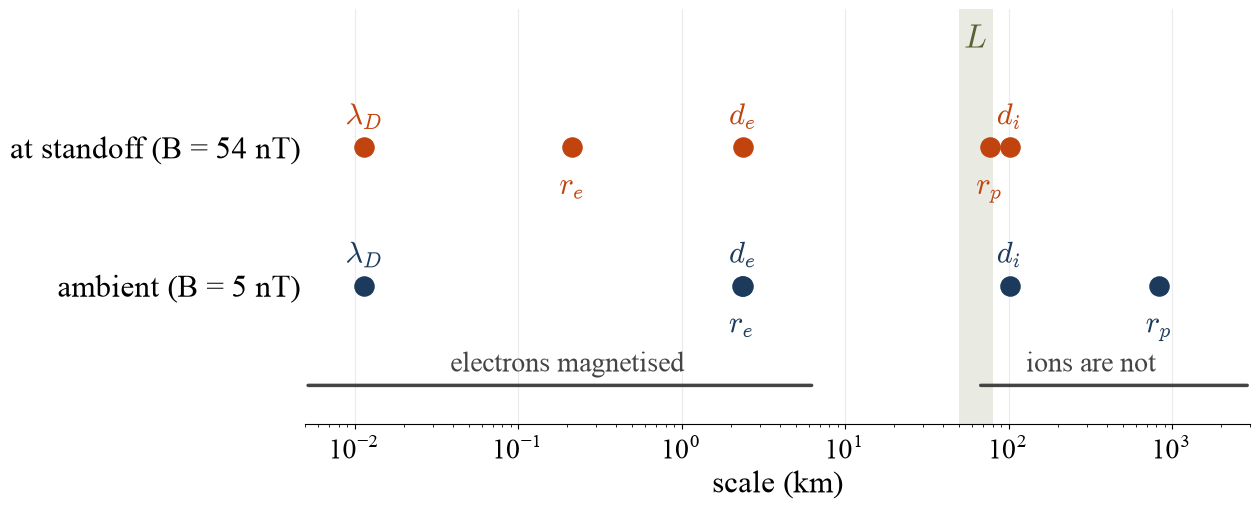

In [49]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'font.size': 20,
})

# --- data ----------------------------------------------------------------
scales = {
    'at standoff (B = 54 nT)':      {r'$\lambda_D$': 0.0115, r'$r_e$': 0.215, r'$d_e$': 2.38,
                         r'$r_p$': 76.8, r'$d_i$': 101.8},
    'ambient (B = 5 nT)':          {r'$\lambda_D$': 0.0115, r'$r_e$': 2.34,  r'$d_e$': 2.38,
                         r'$d_i$': 101.8, r'$r_p$': 835},
}

palette = ['#c1440e', '#1b3a5c']

offsets = {r'$\lambda_D$': 16, r'$d_e$': 16, r'$d_i$': 16,
           r'$r_e$': -34, r'$r_p$': -34}

fig, ax = plt.subplots(figsize=(13, 5.5))

# obstacle scale band
ax.axvspan(50, 80, alpha=0.18, color='#8a8f5c', zorder=0, lw=0)
ax.text(63, 1.72, r'$L$', ha='center', color='#5c6136', fontsize=24)

for i, (env, d) in enumerate(scales.items()):
    y = 1 - i
    ax.scatter(list(d.values()), [y] * len(d),
               s=190, color=palette[i], zorder=3)
    for name, val in d.items():
        ax.annotate(name, (val, y), textcoords='offset points',
                    xytext=(0, offsets[name]), ha='center',
                    color=palette[i], fontsize=22)

# --- the claim -----------------------------------------------------------
ax.annotate('', xy=(5e-3, -0.72), xytext=(6.5, -0.72),
            arrowprops=dict(arrowstyle='-', lw=2.5, color='#444'))
ax.text(0.2, -0.62, 'electrons magnetised', ha='center',
        fontsize=20, color='#444')

ax.annotate('', xy=(65, -0.72), xytext=(3e3, -0.72),
            arrowprops=dict(arrowstyle='-', lw=2.5, color='#444'))
ax.text(320, -0.62, 'ions are not', ha='center',
        fontsize=20, color='#444')

ax.set_xscale('log')
ax.set_xlim(5e-3, 3e3)
ax.set_ylim(-1.0, 2.0)
ax.set_yticks([1, 0])
ax.set_yticklabels(scales.keys(), fontsize=22)
ax.set_xlabel('scale (km)', fontsize=22)
ax.grid(axis='x', alpha=0.25)
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', length=0)
for side in ('top', 'right', 'left'):
    ax.spines[side].set_visible(False)

fig.tight_layout()
fig.savefig('../figures/scale_hierarchy_slide.pdf')
plt.show()

Conclusions:
- Electron gyroradii always smaller than anomaly size, so they are always magnetised
- Proton gyroradius is larger than anomaly size at ambient, so they are not magnetised at ambient
- Proton gyroradius is on the upper edge of anomaly size estimate bound (from Tsunakawa 2015), so sometimes magnetised at standoff
- Inertial lengths independent of B; anomaly is smaller than ion decoupling scale and larger than electron decoupling scale, so reconnection must be electron-only
- Debye lengths five orders smaller than everything else, i.e. system is always quasi-neutral, i.e. no charge separation occurs.

In [31]:
# --- Validation against Stanier et al. 2024 -----------------------------
# SW parameters (from Halekas 2014 event)
n_st   = 12.5e6     # m^-3
v_st   = 300e3      # m/s
B_st   = 7.5e-9     # T
rho_st = n_st * m_p

# Check 1: does our d_e reproduce their quoted 1.5 km?
print(f"d_e = {d_inertial(m_e, n_st)/1e3:.2f} km   (Stanier: ~1.5 km)")

# Check 2: cycle time. They quote 0.2 / Omega_ci at B_IMF.
Omega_ci = e * B_st / m_p
print(f"cycle time = {0.2/Omega_ci*1e3:.1f} ms")

# Check 3: standoff on their geometry (d_src = 15 km, surface at z=0)
# B_surf not quoted directly - it's set by matching a 3D ring dipole of moment 3e13 A m^-2 to a 20 km standoff. Invert instead: what B_surf does our formula need to give z_so = 20 km at d = 15 km?
P_st   = kappa * rho_st * v_st**2
B_so_st = np.sqrt(2 * mu_0 * P_st)
print(f"B_so = {B_so_st*1e9:.1f} nT")
B_surf_implied = B_so_st * (20/15 + 1)**3
print(f"implied B_surf = {B_surf_implied*1e9:.0f} nT")

d_e = 1.50 km   (Stanier: ~1.5 km)
cycle time = 278.4 ms
B_so = 64.5 nT
implied B_surf = 820 nT


**Validation against Stanier et al. 2024**

**d_e = 1.50 km** vs their quoted ~1.5 km. Exact agreement; confirms the
inertial length function and unit handling.

**Cycle time = 278 ms** (0.2/Ω_ci at B_IMF = 7.5 nT). This is the measured
tearing cycle, ~130× longer than the Alfvén crossing time of the structure
(2.2 ms). A reconnection cycle is not one Alfvén crossing: the mode must grow,
form an island, reconnect flux and eject it. The Alfvén time is therefore a lower bound
on the reconnection timescale and not an estimate of it.

**Implied B_surf = 820 nT.** Inverting z_so for their geometry (d = 15 km,
standoff 20 km, their SW parameters giving B_so = 64.5 nT). Consistent with a
strong lunar anomaly (Tsunakawa 2015 peak: 718 nT). Weak check only — their
2D line dipole falls as r^-2, not r^-3, κ = 0.88 is our choice.